In [1]:
from google.colab import files
import io
import pandas as pd
import matplotlib.pyplot as plt
uploaded = files.upload()

ModuleNotFoundError: No module named 'google'

# Abrindo o CSV

In [9]:
df = pd.read_csv(
    io.BytesIO(uploaded['netflix_titles.csv']), comment="#"
  )
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020.0,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021.0,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021.0,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021.0,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021.0,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


# PANDAS - Transformação em Dicionário de Dicionários

In [10]:
df = df[['show_id','type','title', 'cast', 'country', 'date_added','release_year','duration', 'listed_in']]
df.head()

,show_id,type,title,cast,country,date_added,release_year,duration,listed_in
0,s1,Movie,Dick Johnson Is Dead,NaN,United States,"September 25, 2021",2020.0,90 min,Documentaries
1,s2,TV Show,Blood & Water,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021.0,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries"
2,s3,TV Show,Ganglands,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021.0,1 Season,"Crime TV Shows, International TV Shows, TV Act..."
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,"September 24, 2021",2021.0,1 Season,"Docuseries, Reality TV"
4,s5,TV Show,Kota Factory,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021.0,2 Seasons,"International TV Shows, Romantic TV Shows, TV ..."


# Dicionário de Dicionários

In [4]:
data_dict = df.set_index('show_id').to_dict(orient='index')

# Pegando os dados para criar os gráficos

In [12]:
anoLancamento = [
    dados["release_year"]
    for dados in data_dict.values()
]

qtdCategorias = [
    len(dados.get("listed_in", "").split(","))
    for dados in data_dict.values()
    if isinstance(dados.get("listed_in"), str)
]

qtdAtores = [
    len(dados.get("cast", "").split(","))
    for dados in data_dict.values()
    if isinstance(dados.get("cast"), str)
]

# Lista temporária de todos os tipos
lista_tipos = [
    dados.get('type')
    for dados in data_dict.values()
    if dados.get('type')
]

# Contagem manual da frequência
qtde_por_tipo = {}
for tipo in lista_tipos:
    qtde_por_tipo[tipo] = qtde_por_tipo.get(tipo, 0) + 1

dicionario_categoria = qtde_por_tipo

# Gráficos numéricos

In [22]:
def printNumerico(lista_dados: list, nome_feature: str, num_bins: int = 10):
  fig, axs = plt.subplots(2, 2, figsize=(14,10))

  #Lista original
  axs[0, 0].plot(lista_dados, marker='o', linestyle='-', color='blue')
  axs[0, 0].set_title(f"1. Distribuição Original de {nome_feature}")
  axs[0, 0].set_ylabel(nome_feature)
  axs[0, 0].grid(True, linestyle="--", alpha=0.6)

  # Lista ordenada
  axs[0, 1].plot(sorted(lista_dados), marker='o', linestyle='-', color='blue')
  axs[0, 1].set_title(f"2. Distribuição Ordenada de {nome_feature}")
  axs[0, 1].set_ylabel(nome_feature)
  axs[0, 1].grid(True, linestyle="--", alpha=0.6)

  # Histograma
  axs[1, 0].hist(lista_dados, bins=num_bins, color="orange", edgecolor="black", alpha=0.7)
  axs[1, 0].set_title(f"3. Histograma de {nome_feature}")
  axs[1, 0].set_xlabel(nome_feature)
  axs[1, 0].set_ylabel("Frequência / Contagem")
  axs[1, 0].grid(True, linestyle="--", alpha=0.6)

  #Boxplot
  axs[1, 1].boxplot(lista_dados, patch_artist=True)
  axs[1, 1].set_title(f"4. Boxplot de {nome_feature}")
  axs[1, 1].set_xlabel(nome_feature)

  # Ajusta espaçamento
  plt.tight_layout()
  plt.show()


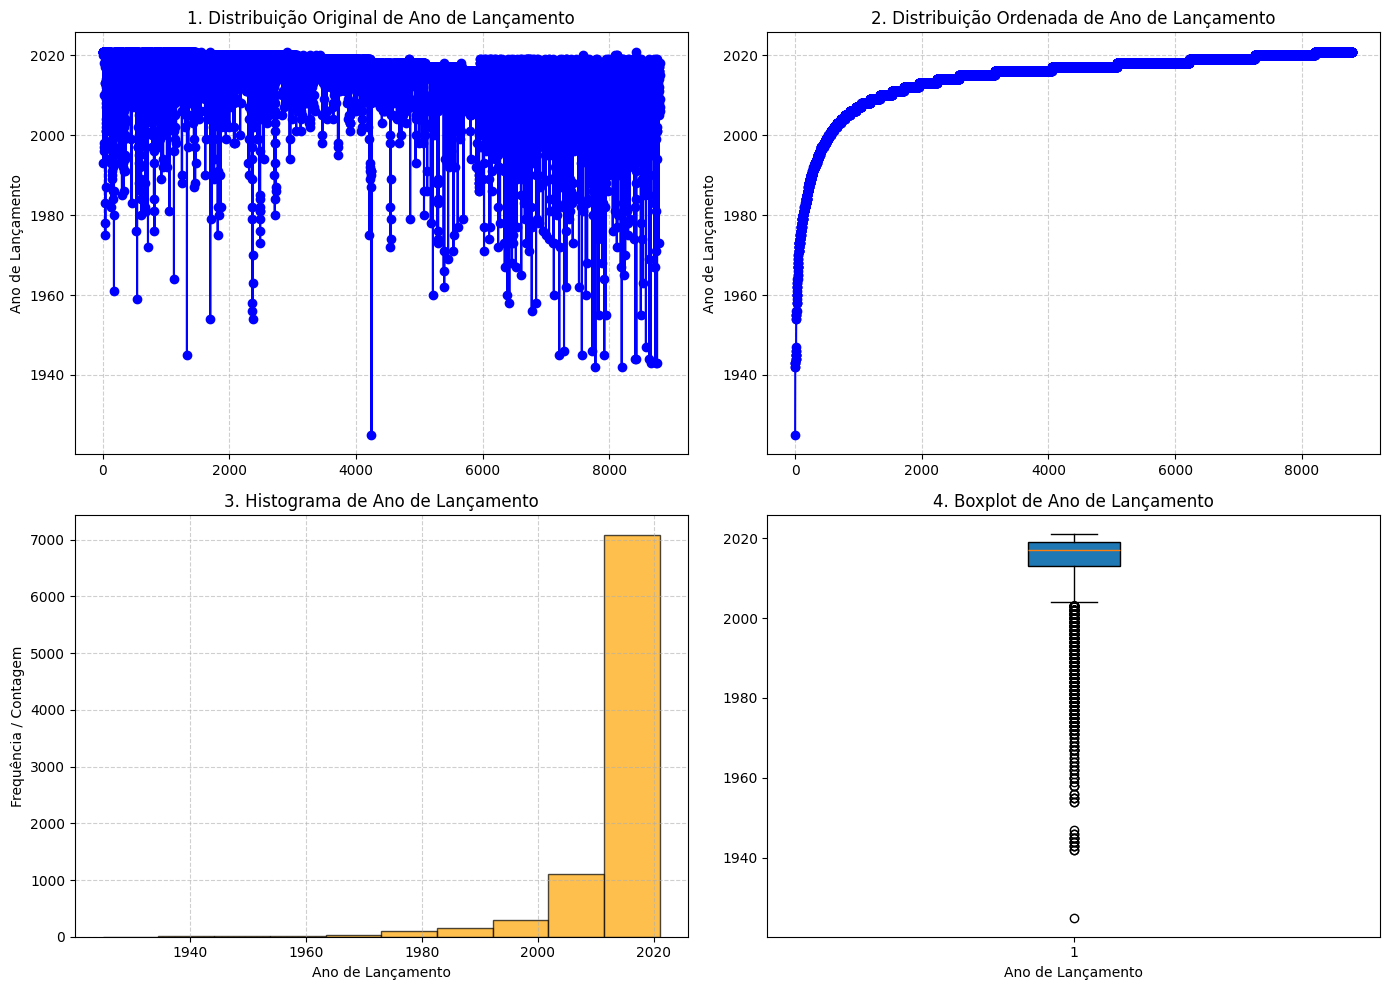

In [18]:
anoLancamento_limpo = [
    ano
    for ano in anoLancamento
    if isinstance(ano, (int, float)) and ano == ano
]

printNumerico(anoLancamento_limpo, "Ano de Lançamento")


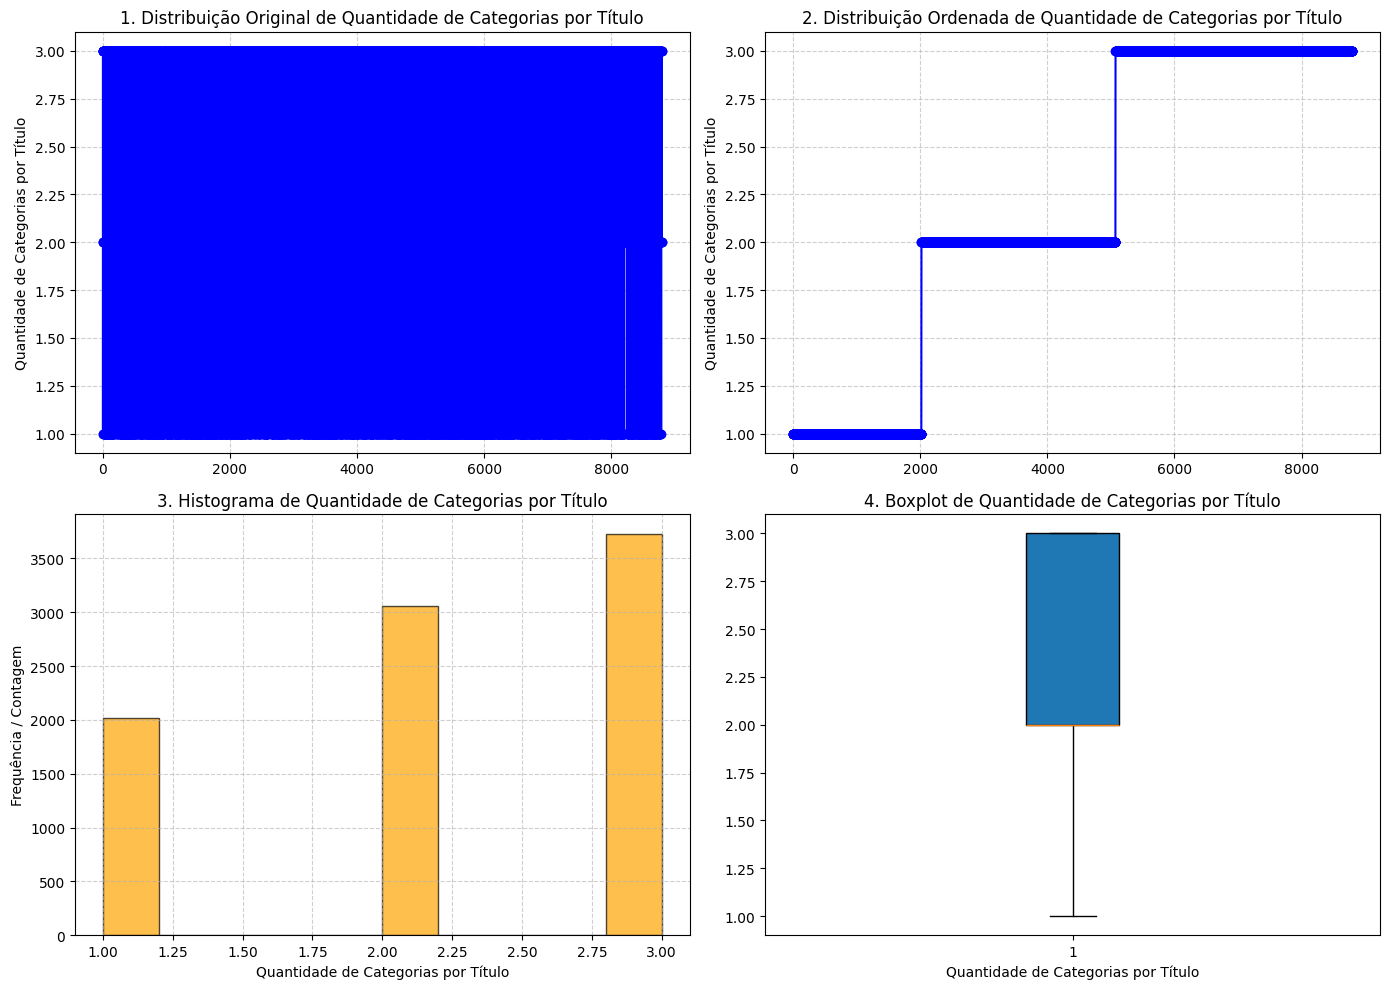

In [19]:
printNumerico(qtdCategorias, "Quantidade de Categorias por Título")

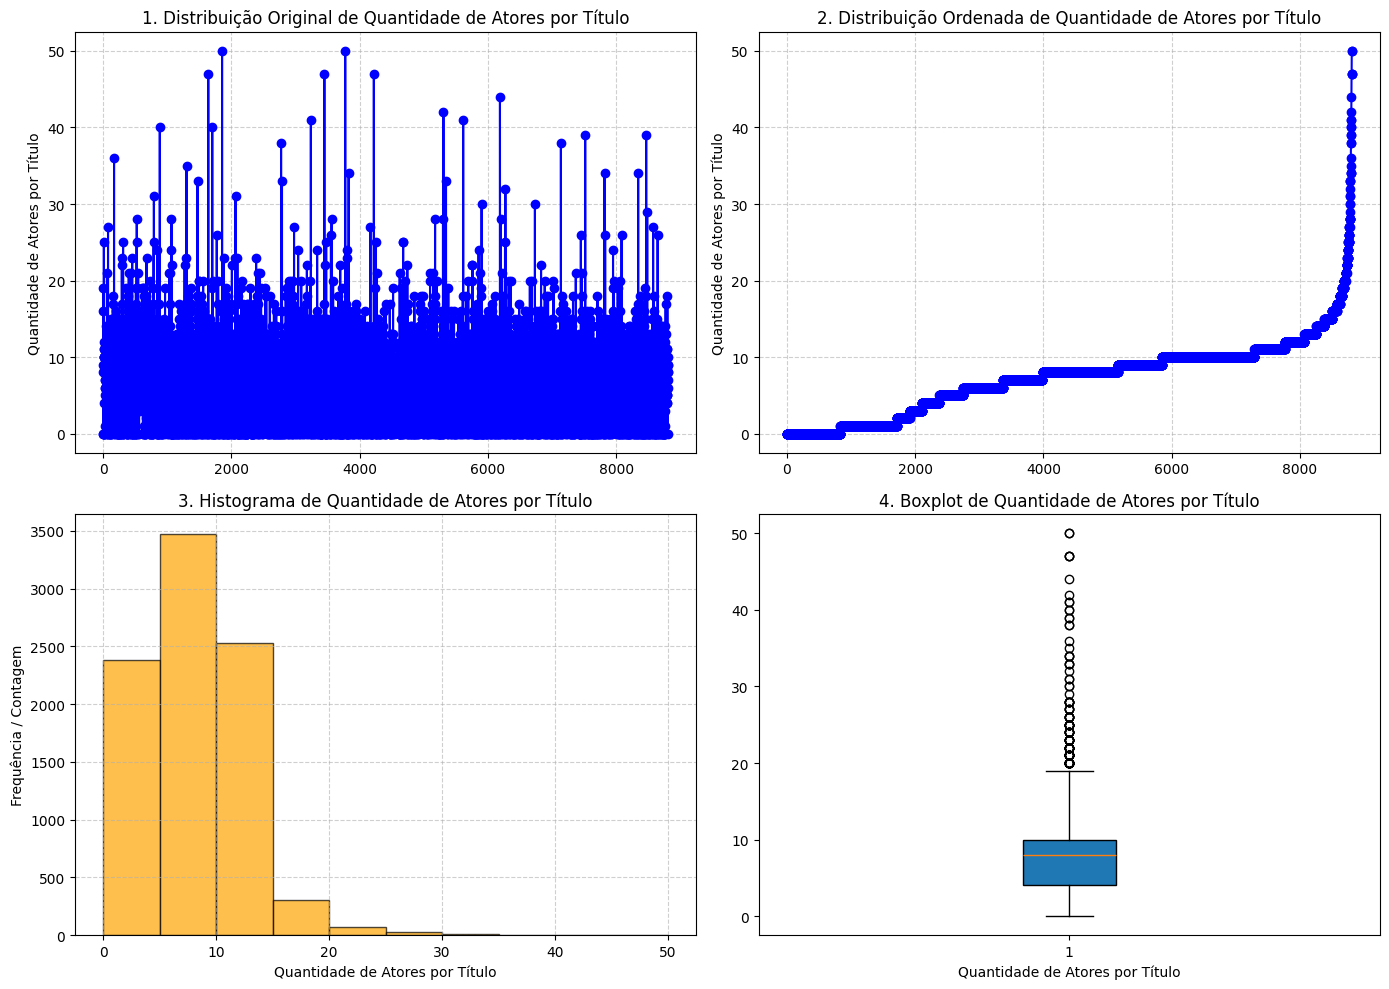

In [17]:
printNumerico(qtdAtores, "Quantidade de Atores por Título")

# Gráfico de pizza e barras

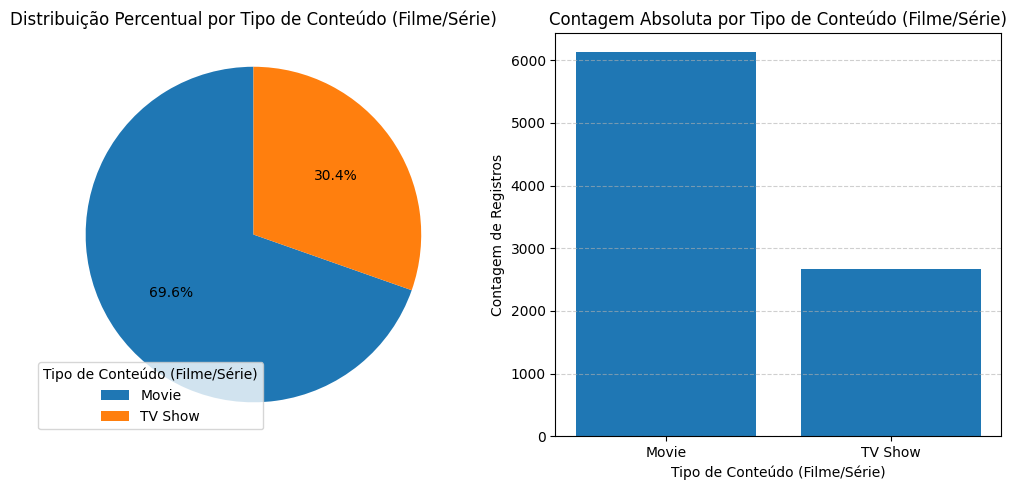

In [23]:
def printCategoria(dicionario_qtde: dict, nome_categoria: str):

  fig, axs = plt.subplots(1, 2, figsize=(10,5))

  #Pizza
  axs[0].pie(
          dicionario_qtde.values(),
          autopct='%1.1f%%',
          startangle=90
      )
  axs[0].set_title(f"Distribuição Percentual por {nome_categoria}")
  axs[0].legend(dicionario_qtde.keys(), title=nome_categoria, loc="best")
  axs[0].axis("equal")

  #Colunas
  axs[1].bar(dicionario_qtde.keys(), dicionario_qtde.values())
  axs[1].set_title(f"Contagem Absoluta por {nome_categoria}")
  axs[1].set_ylabel("Contagem de Registros")
  axs[1].set_xlabel(nome_categoria)
  axs[1].grid(axis='y', linestyle="--", alpha=0.6)

  # Ajusta espaçamento
  plt.tight_layout()
  plt.show()

printCategoria(dicionario_categoria, "Tipo de Conteúdo (Filme/Série)")

# Dicionário filtrado com **uma** restrição

In [30]:
def analisa_filtro_ano(data_dict: dict, ano_limite: int, printNumerico, printCategoria):
    data_dict_filtrado_1 = {
        key: dados
        for key, dados in data_dict.items()
        if dados.get('release_year') is not None and dados.get('release_year') >= ano_limite
    }

    print(f"\n--- ANÁLISE DO FILTRO: Lançamento >= {ano_limite} ---")
    print(f"Dataset Original: {len(data_dict)} registros")
    print(f"Dataset Filtrado 1: {len(data_dict_filtrado_1)} registros\n")

    if len(data_dict_filtrado_1) == 0:
        print("AVISO: O filtro não retornou registros. Gráficos não serão gerados.")
        return

    dados_filtrados = data_dict_filtrado_1.values()

    anoLancamento_F1 = [
        dados["release_year"] for dados in dados_filtrados
    ]

    qtdCategorias_F1 = [
        len(dados.get("listed_in", "").split(","))
        for dados in dados_filtrados
        if isinstance(dados.get("listed_in"), str)
    ]

    qtdAtores_F1 = [
        len(dados.get("cast", "").split(","))
        for dados in dados_filtrados
        if isinstance(dados.get("cast"), str)
    ]

    lista_tipos = [
        dados.get('type') for dados in dados_filtrados if dados.get('type')
    ]

    qtde_por_tipo_F1 = {}
    for tipo in lista_tipos:
        qtde_por_tipo_F1[tipo] = qtde_por_tipo_F1.get(tipo, 0) + 1

    dicionario_categoria_F1 = qtde_por_tipo_F1

    # Gráficos Numéricos
    printNumerico(anoLancamento_F1, f"Ano de Lançamento (Filtrado >= {ano_limite})")
    printNumerico(qtdCategorias_F1, f"Quantidade de Categorias (Filtrado >= {ano_limite})")
    printNumerico(qtdAtores_F1, f"Quantidade de Atores (Filtrado >= {ano_limite})")

    # Gráfico de Categoria
    if dicionario_categoria_F1:
        printCategoria(dicionario_categoria_F1, f"Tipo de Conteúdo (Filtrado >= {ano_limite})")


--- ANÁLISE DO FILTRO: Lançamento >= 2020 ---
Dataset Original: 8807 registros
Dataset Filtrado 1: 1541 registros



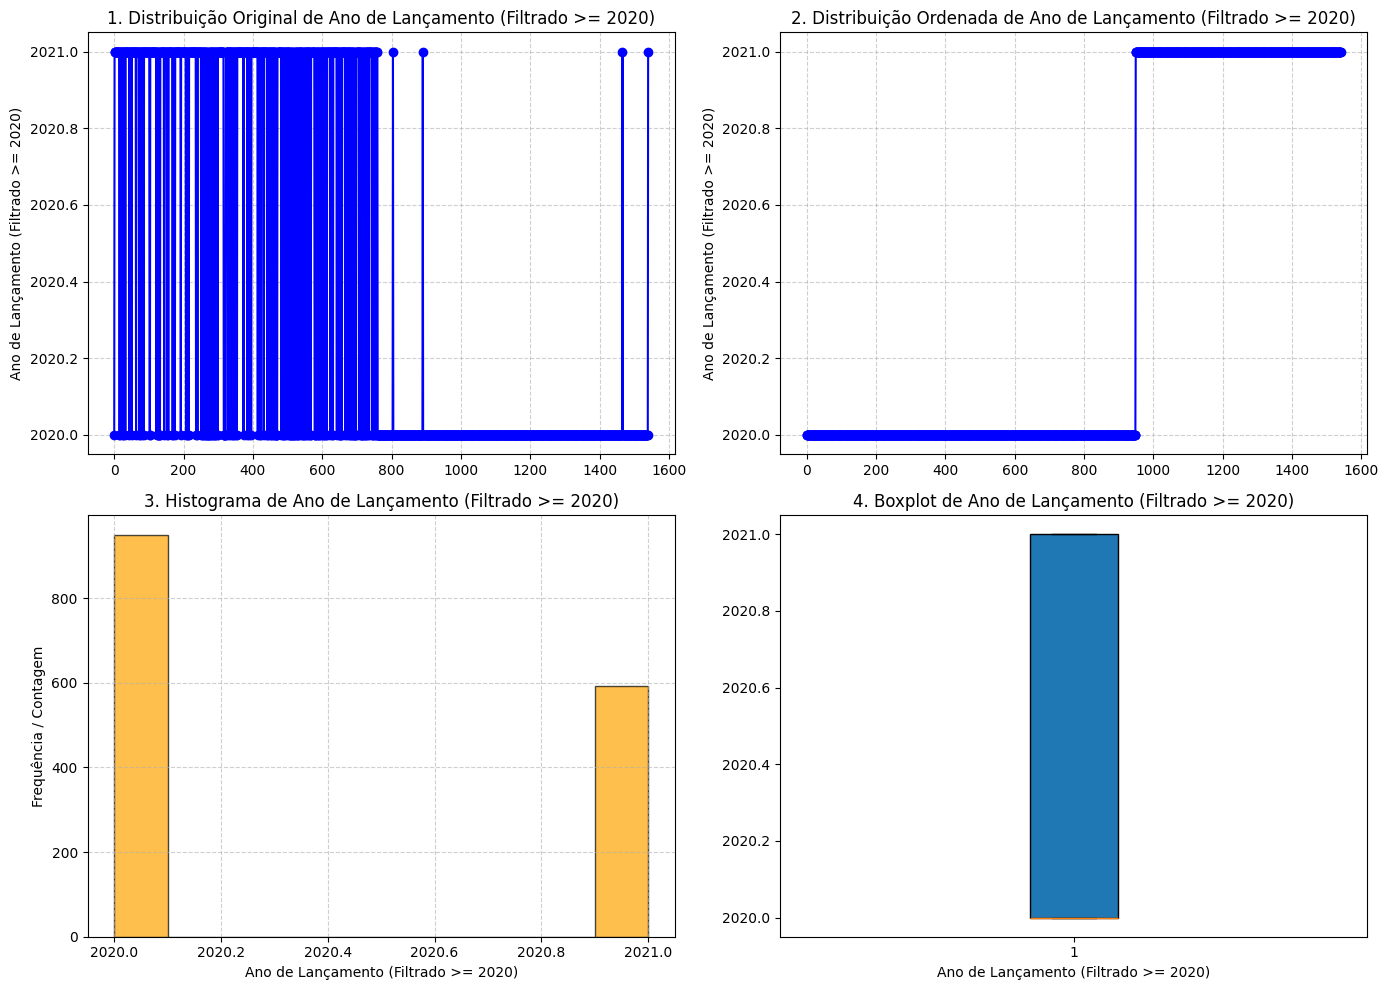

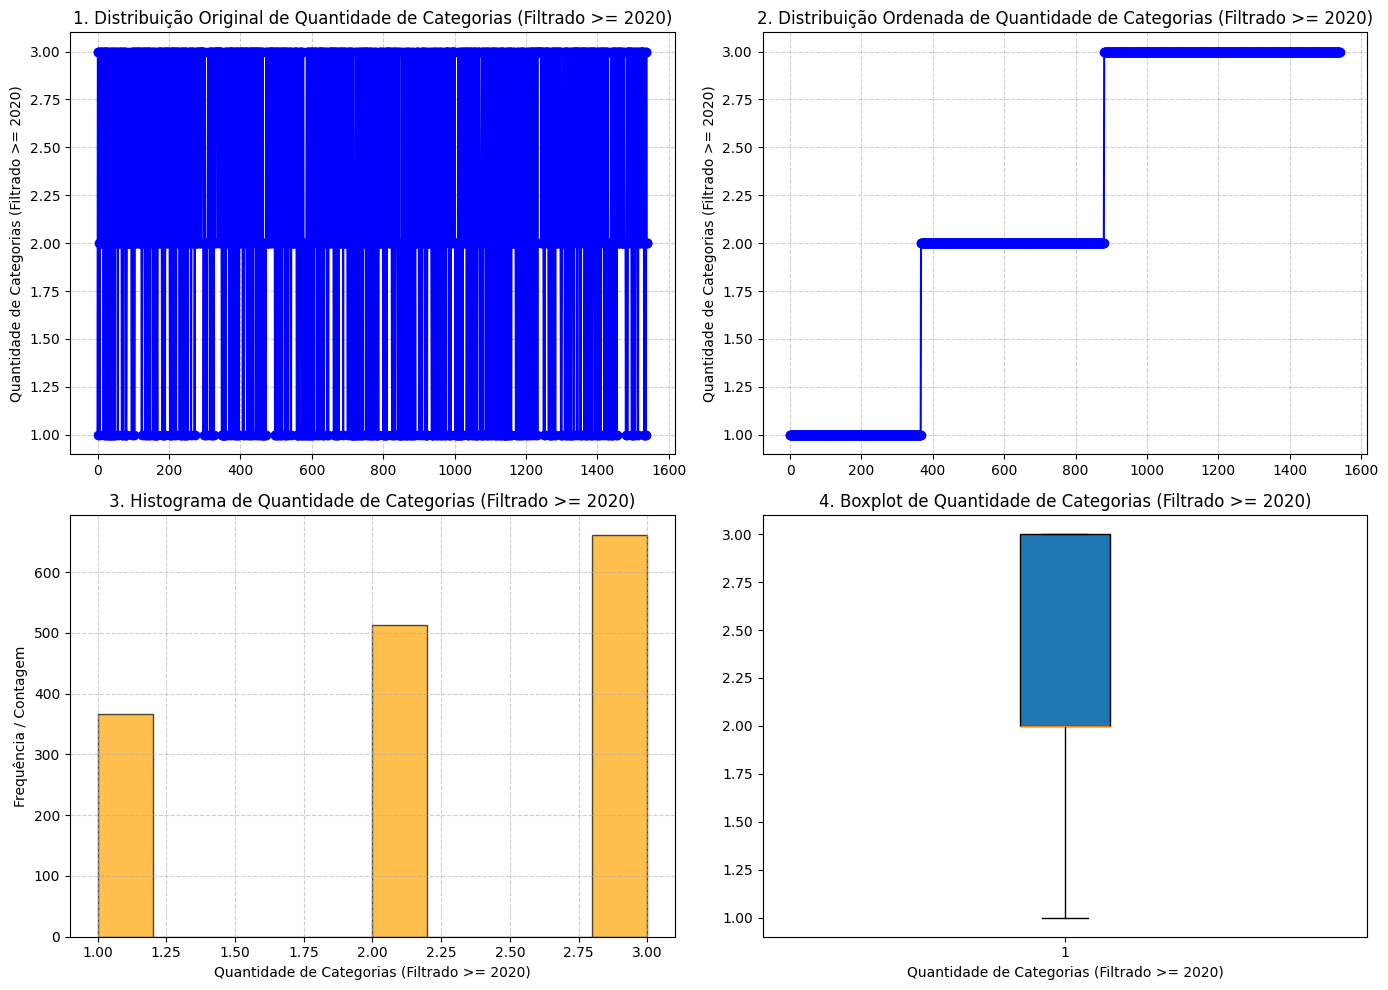

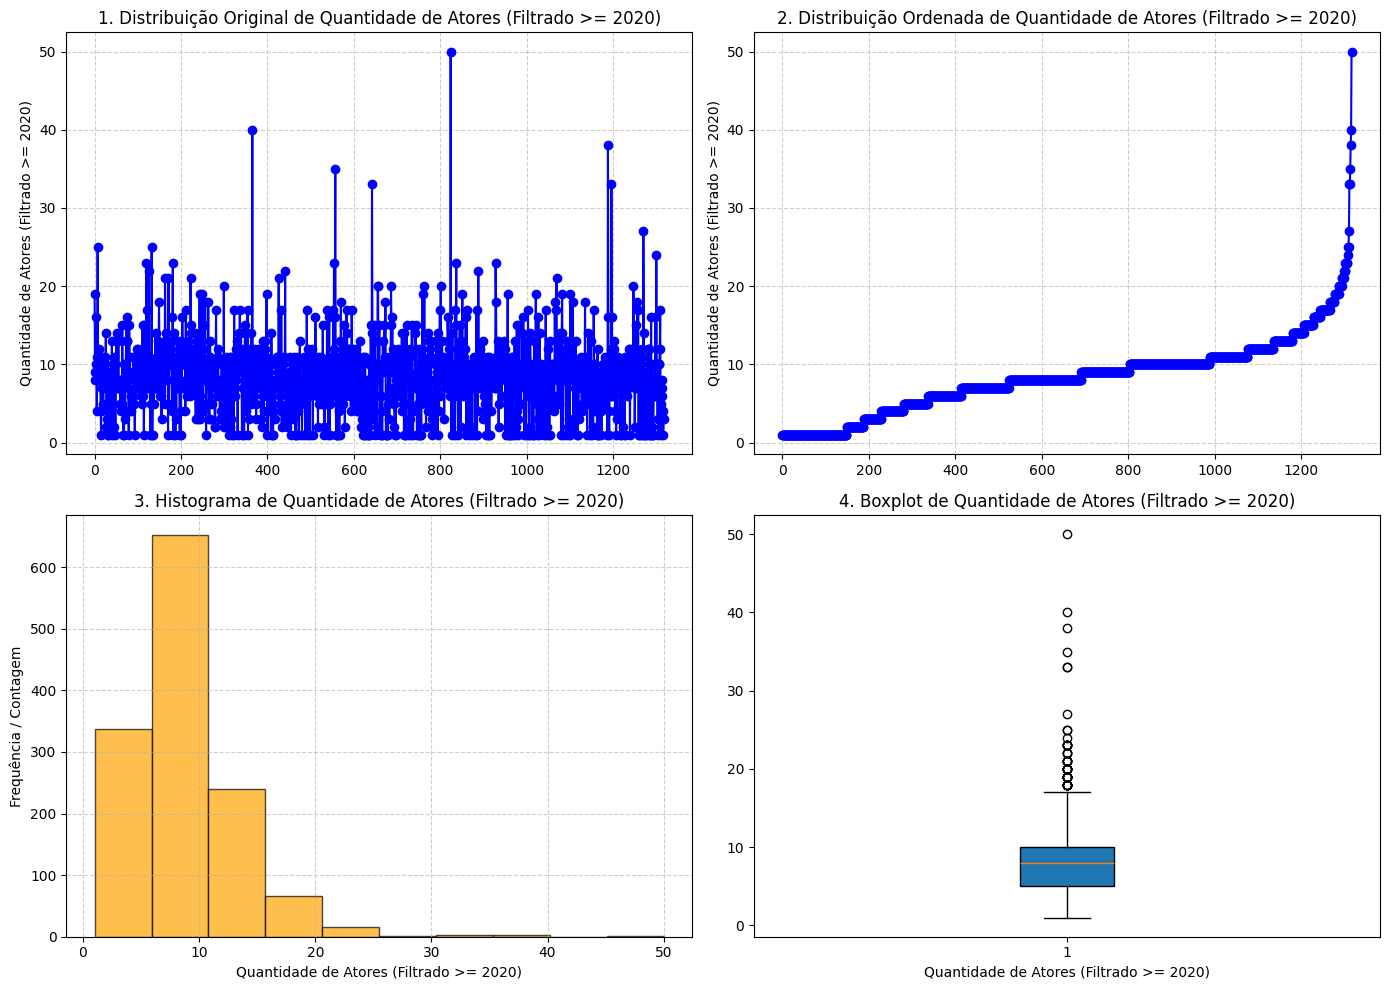

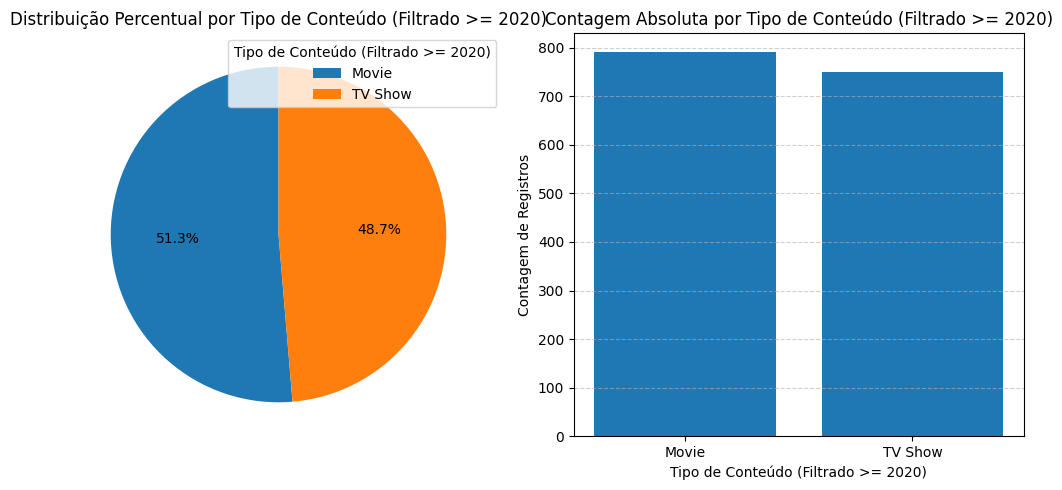

In [31]:
ano_de_corte = 2020
analisa_filtro_ano(data_dict, ano_de_corte, printNumerico, printCategoria)

# Dicionário com **duas** restrições

In [37]:
def analisa_filtro_dupla_restricao(data_dict: dict, tipo_restricao: str, ano_limite: int, printNumerico, printCategoria):
    data_dict_filtrado_2 = {
        key: dados
        for key, dados in data_dict.items()
        if dados.get('type') == tipo_restricao and
           dados.get('release_year') is not None and dados.get('release_year') <= ano_limite
    }

    print(f"\n--- ANÁLISE DO FILTRO: {tipo_restricao} E Lançamento <= {ano_limite} ---")
    print(f"Dataset Original: {len(data_dict)} registros")
    print(f"Dataset Filtrado 2: {len(data_dict_filtrado_2)} registros\n")

    if len(data_dict_filtrado_2) == 0:
        print("AVISO: O filtro não retornou registros. Gráficos não serão gerados.")
        return

    dados_filtrados = data_dict_filtrado_2.values()

    anoLancamento_F2 = [
        dados["release_year"] for dados in dados_filtrados
    ]

    qtdCategorias_F2 = [
        len(dados.get("listed_in", "").split(","))
        for dados in dados_filtrados
        if isinstance(dados.get("listed_in"), str)
    ]

    qtdAtores_F2 = [
        len(dados.get("cast", "").split(","))
        for dados in dados_filtrados if dados.get("cast")
        if isinstance(dados.get("cast"), str)
    ]

    qtde_por_genero_F2 = {}
    for dados in dados_filtrados:
        lista_generos_do_registro = dados.get('listed_in')
        if lista_generos_do_registro and isinstance(lista_generos_do_registro, str):
            generos_separados = [g.strip() for g in lista_generos_do_registro.split(',')]
            for genero in generos_separados:
                qtde_por_genero_F2[genero] = qtde_por_genero_F2.get(genero, 0) + 1

    dicionario_categoria_F2 = qtde_por_genero_F2

    # Gráficos Numéricos
    printNumerico(anoLancamento_F2, f"Ano Lançamento ({tipo_restricao} <= {ano_limite})")
    printNumerico(qtdCategorias_F2, f"Qtd Categorias ({tipo_restricao} <= {ano_limite})")
    printNumerico(qtdAtores_F2, f"Qtd Atores ({tipo_restricao} <= {ano_limite})")

    # Gráfico de Categoria (Usando Top 8 GÊNEROS)
    if dicionario_categoria_F2:
        top_generos = sorted(dicionario_categoria_F2.items(), key=lambda item: item[1], reverse=True)[:8]
        dicionario_top8_generos = dict(top_generos)

        printCategoria(dicionario_top8_generos, f"Gêneros (Top 8 - {tipo_restricao} <= {ano_limite})")


--- ANÁLISE DO FILTRO: TV Show E Lançamento <= 2000 ---
Dataset Original: 8807 registros
Dataset Filtrado 2: 53 registros



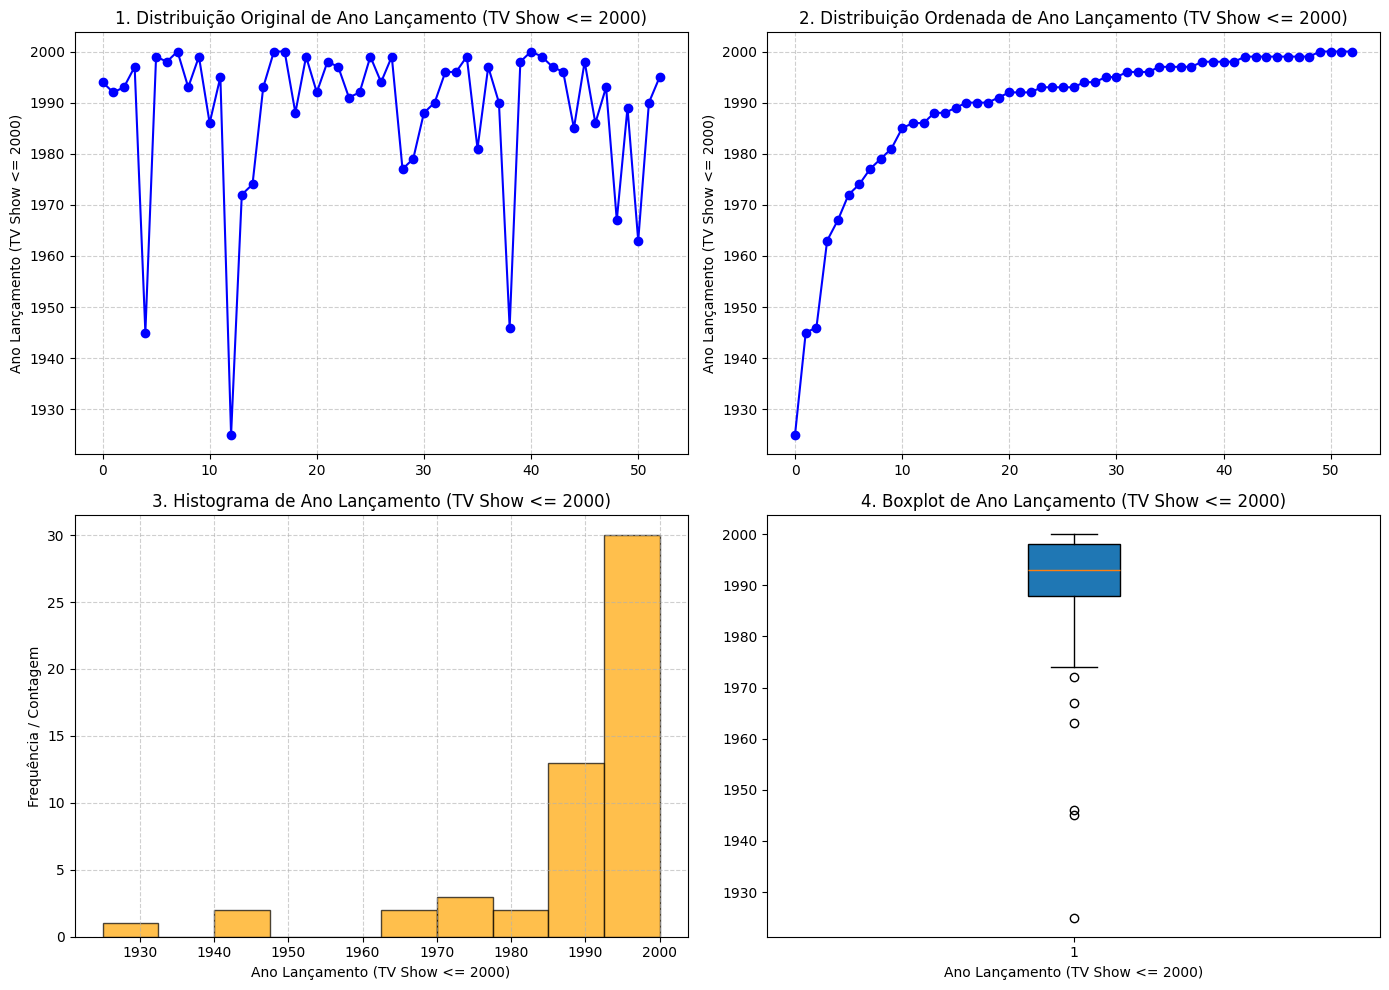

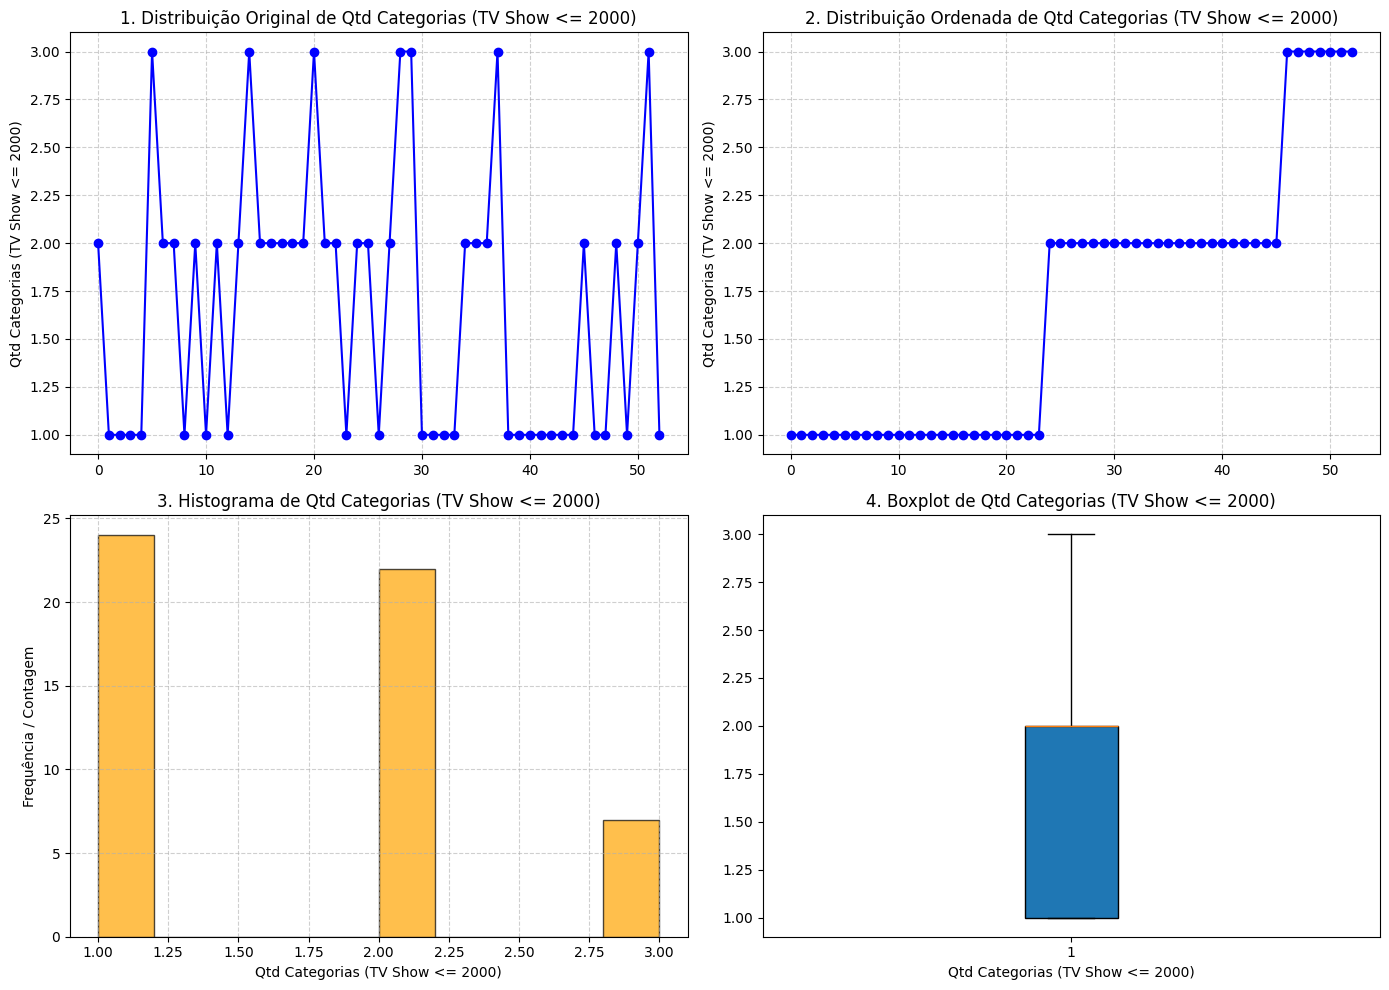

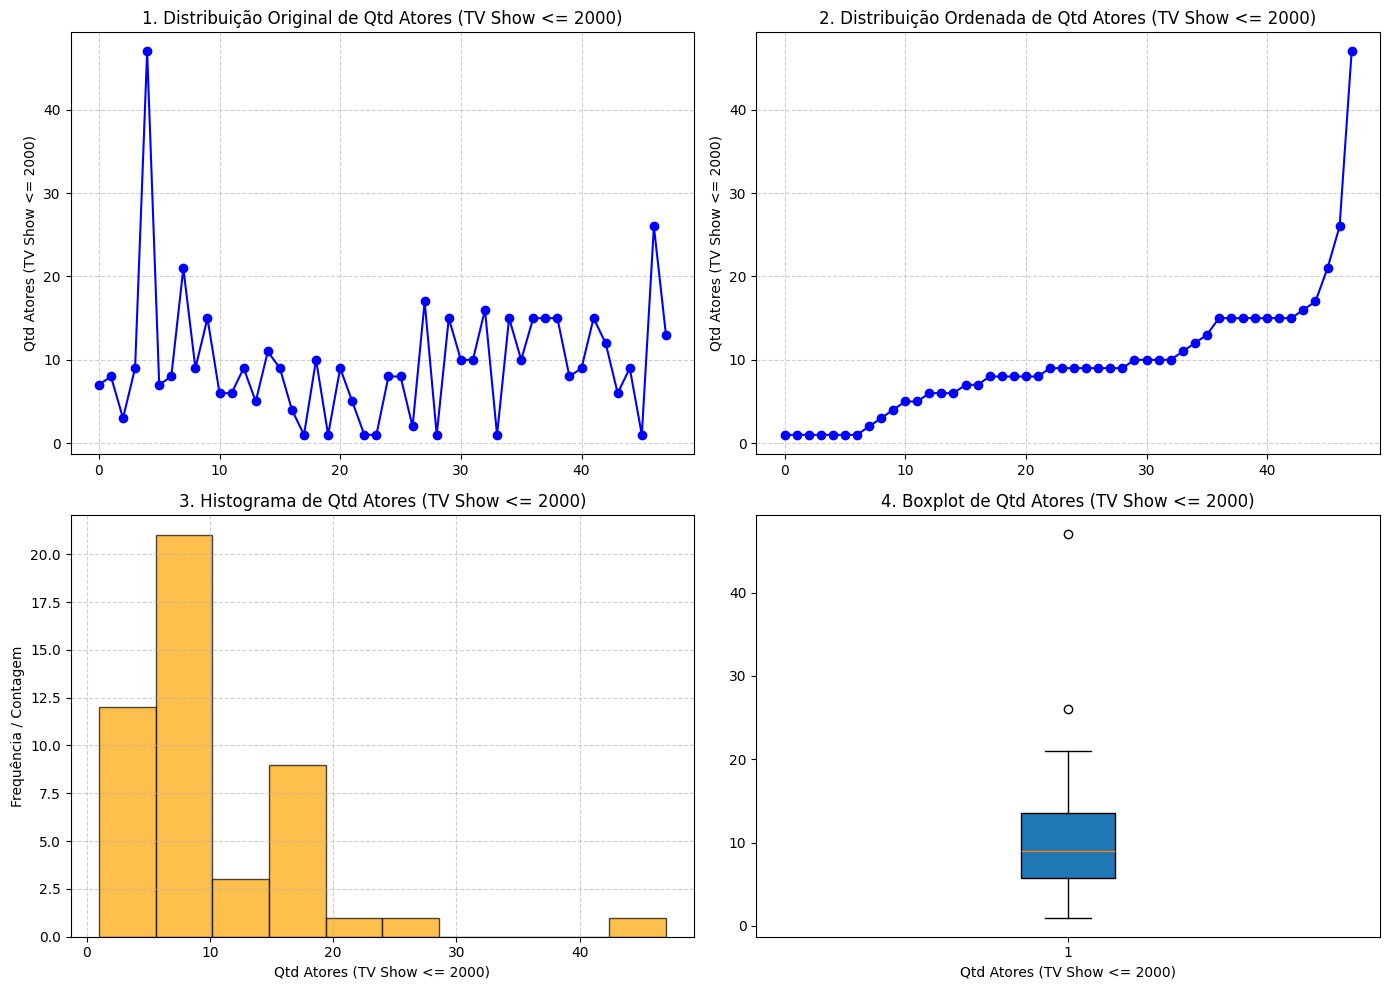

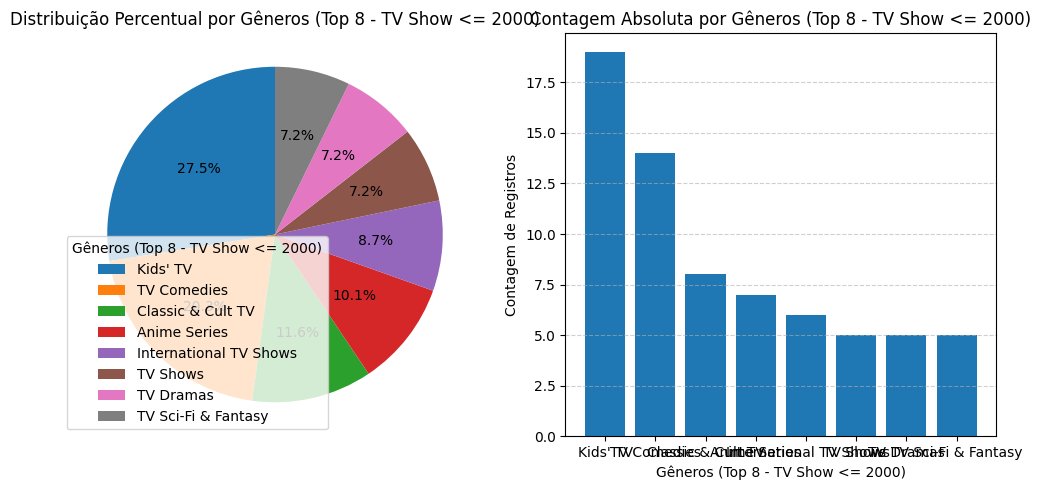

In [38]:
tipo_de_corte = 'TV Show'
ano_de_corte = 2000
analisa_filtro_dupla_restricao(data_dict, tipo_de_corte, ano_de_corte, printNumerico, printCategoria)